In [261]:
#Initializing Stuff
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.optimize import curve_fit
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append( '/Users/Dell/Documents/RESEARCH/tmsi-python-interface-main/tmsi-python-interface-main/TMSiFileFormats/file_readers')
from poly5reader import Poly5Reader



In [ ]:
#Initializing Stuff (If I am on my desktop)
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.optimize import curve_fit
import pandas as pad
import tkinter as tk
from tkinter import filedialog
import os
sys.path.append('/Users/Valie/Documents/Electrostim')
from poly5reader import Poly5Reader


In [ ]:
#Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27\\20250627"
root =tk.Tk()
root.withdraw()  # Hide the root window
#select data (studying FLX only)
flexion_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Flexion Data File")
#select baseline data (studying FLX only)
baseline_data = filedialog.askopenfilename(initialdir=folder_path, title="Select Baseline file")


In [ ]:
accel_data_dict = {}

file_path = flexion_data
reader = Poly5Reader(file_path)
    #Extract Raw Samples (Channels x Samples)
samples = reader.samples
ch_names = reader.ch_names
sample_rate = reader.sample_rate
print(reader.ch_names)


trigger_channel = ['TRIGGERS']
trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
trigger_samples = samples [trigger_indices, :]
time_axis = np.arange(trigger_samples.shape[1])/ sample_rate


In [ ]:
print(reader.ch_names[73])

In [ ]:
trigger = samples[73,:]
emg = samples[1:65]

grid_order = [
    16, 15, 14, 13, 12, 8, 4, 0,  # Row 1 (17,16,15,14,13, 9, 5, 1)
    21, 20, 19, 18, 17, 9, 5, 1,  # Row 2 (22…2)
    26, 25, 24, 23, 22, 10, 6, 2,  # Row 3
    31, 30, 29, 28, 27, 11, 7, 3,  # Row 4
    32, 33, 34, 35, 36, 52, 56, 60,  # Row 5 (33…61)
    37, 38, 39, 40, 41, 53, 57, 61,  # Row 6
    42, 43, 44, 45, 46, 54, 58, 62,  # Row 7
    47, 48, 49, 50, 51, 55, 59, 63   # Row 8
]

<![alt text](image.png)>

Indexed starting at 0, so channel 30 = channel 31
Channel 17 = 1-1 = R1C1

In [ ]:
%matplotlib ipympl
#RAW EMG CHANNELS BEFORE FILTERINGddd

selected_channels = [35, 30, 37]  # Replace with the exact indices you want


# Number of selected channels
num_selected = len(selected_channels)


# Create subplots for each selected channel
fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
plt.subplots_adjust(hspace=0.5)

# Loop over the selected channels and plot each one
for ax, ch_idx in zip(axes, selected_channels):
    ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(loc="upper right")

# Set common labels and title
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG Channels", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
#Smoothing/Bandpass Filtering
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])

In [ ]:
fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 450.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

In [ ]:

# === 1) BAND-PASS raw EMG ===
# emg: (n_channels, n_samples)


#selected_channels = [0, 30, 32] # Replace with the exact indices you want

filtered = np.zeros_like(emg)
for ch in range(emg.shape[0]):
    filtered[ch, :] = bandpass_filter(emg[ch, :],
                                       lowcut, highcut,
                                       fs, bp_order)

# === 2) LOW-PASS SMOOTH  *filtered* data ===
smoothed = lpf_smooth(filtered, lpf_cutoff, fs, lpf_order)

# === 3) PLOT the SMOOTHED EMG ===
fig, axes = plt.subplots(len(selected_channels), 1,
                         sharex=True, figsize=(12, 6))
plt.subplots_adjust(hspace=0.4)

for ax, ch in zip(axes, selected_channels):
    ax.plot(time_axis, smoothed[ch], color='C0', alpha=0.8)
    ax.set_ylabel(f"Ch {ch} (µV)")
    ax.set_title(f"Channel {ch} Smoothed EMG")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EMG → Band-pass → Low-pass Smoothing", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
# Plot the trigger channel
plt.figure(figsize=(15, 4))
plt.plot(time_axis, trigger, label="Trigger Channel (73)")
plt.xlabel("Time (s)")
plt.ylabel("Trigger Value")
plt.title("Trigger Channel (Index 73)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Find falling edges: trigger goes from 1 to 0
falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition

print("Indices where trigger goes from 1 to 0:", falling_edges)

# To get the time between each trigger (in seconds):
falling_times = time_axis[falling_edges]
intervals = np.diff(falling_times)
print("Time between each trigger (s):", intervals)

In [ ]:
#First STA try
# Spike-Triggered Average (STA) using ±50 ms window 

# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    snippet = emg[:, idx - window_samples : idx + window_samples]
    snippets.append(snippet)
snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across triggers
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [0, 30, 32]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Spike-Triggered Average (STA) with Baseline Correction (±50 ms window)


# Parameters
window_ms = 50  # window before and after trigger in ms
window_samples = int(window_ms * sample_rate / 1000)  # samples per side, /1000 to convert ms to samples
total_window = 2 * window_samples  # total window size (samples)

# Find trigger events (rising edges)
trigger_diff = np.diff(trigger)
trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1  # adjust for diff offset

# Only keep triggers far enough from start/end for window
valid_triggers = trigger_onsets[
    (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
]

# Extract and baseline-correct EMG snippets around each trigger
snippets = []
for idx in valid_triggers:
    # raw snippet: shape (n_channels, window)
    snippet = emg[:, idx - window_samples : idx + window_samples]
    # compute baseline from pre-spike portion (first window_samples)
    baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
    # subtract baseline to center around zero
    snippet_corrected = snippet - baseline
    snippets.append(snippet_corrected)

snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)

# Compute average across baseline-corrected snippets
sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

# Time axis for window (centered at trigger)
sta_time = np.linspace(-window_ms, window_ms, total_window)

# Plot STA for selected channels
selected_channels = [35, 30, 37]
plt.figure(figsize=(12, 6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')

plt.axvline(0, color='k', linestyle='--', label='Trigger')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('Baseline-corrected EMG (µV)')
plt.title('Spike-Triggered Average (±50 ms window)')
plt.legend()
plt.tight_layout()
plt.show()


 ABOVE = M WAVE YAY?

In [ ]:
# Compute peak-to-peak amplitude for each channel in the STA
# sta: shape (n_channels, window)

peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)

# Example: print or plot for selected channels
for ch in selected_channels:
    print(f"Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

In [255]:
# Get Data   
folder_path = "G:\\My Drive\\Research\\Data\\electrostim_data\\Doug 6-27"
root = tk.Tk()
root.withdraw()  # Hide the root window

# Select multiple flexion data files
flexion_files = filedialog.askopenfilenames(
    initialdir=folder_path,
    title="Select Flexion Data Files"
)

# Select baseline data (single file)
# baseline_data = filedialog.askopenfilename(
#     initialdir=folder_path,
#     title="Select Baseline file"
# )

# flexion_files will be a tuple of file paths
print("Selected flexion files:", flexion_files)
print("Selected baseline file:", baseline_data)

Selected flexion files: ('G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5',)
Selected baseline file: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627/trial_2_FLX-20250627_150914.poly5


In [256]:
# Loop through each selected flexion file
#72 = trigger channel
# aux [3] = iso aux channel
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate
    print(f"Loaded: {file_path}")
    print(reader.ch_names)

    # Extract trigger and EMG data
    trigger_channel = ['TRIGGERS']
    trigger_indices = [ch_names.index(name) for name in trigger_channel if name in ch_names]
    trigger_samples = samples[trigger_indices, :]
    time_axis = np.arange(trigger_samples.shape[1]) / sample_rate

    # Example: extract EMG channels (adjust indices as needed) and triggers
    emg = samples[1:65, :]
    aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
    trigger = samples[72,:]
  
    # processing emg, trigger_samples, etc. for each file

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.
Loaded: G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
['R1C1', 'R1C2', 'R1C3', 'R1C4', 'R1C5', 'R1C6', 'R1C7', 'R1C8', 'R2C1', 'R2C2', 'R2C3', 'R2C4', 'R2C5', 'R2C6', 'R2C7', 'R2C8', 'R3C1', 'R3C2', 'R3C3', 'R3C4', 'R3C5', 'R3C6', 'R3C7', 'R3C8', 'R4C1', 'R4C2', 'R4C3', 'R4C4', 'R4C5', 'R4C6', 'R4C7', 'R4C8', 'R5C1', 'R5C2', 'R5C3', 'R5C4', 'R5C5', 'R5C6', 'R5C7', 'R5C8', 'R6C1', 'R6C2', 'R6C3', 'R6C4', 'R6C5', 'R6C6', 'R6C7', 'R6C8', 'R7C1', 'R7C2', 'R7C3', 'R7C4', 'R7C5', 'R7C6', 'R7C7', 'R7C8', 'R8C1', 'R8C2', 'R8C3', 'R8C4', 'R8C5', 'R8C6', 'R8C7', 'R8C8', 'BIP 01', 'BIP 02', 'BIP 03', 'BIP 04', 'ISO aux', 'ISO aux', 'AUX 1-3', 'AUX 2-1', 'TRIGGERS', 'STATUS', 'Counter 2power24']


In [ ]:
   # Example: extract EMG channels (adjust indices as needed) and triggers
fig,ax = plt.subplots()
reader = Poly5Reader(flexion_files[0])
samples = reader.samples

emg = samples[1:65, :]
aux = samples[66:71, :]  # Assuming aux channels are from 66 to 72
ax.plot(aux[3,:], label=f"Aux Channel 66 - {os.path.basename(file_path)}")
trigger = samples[72,:]
#ax.plot(trigger[:-100])
plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


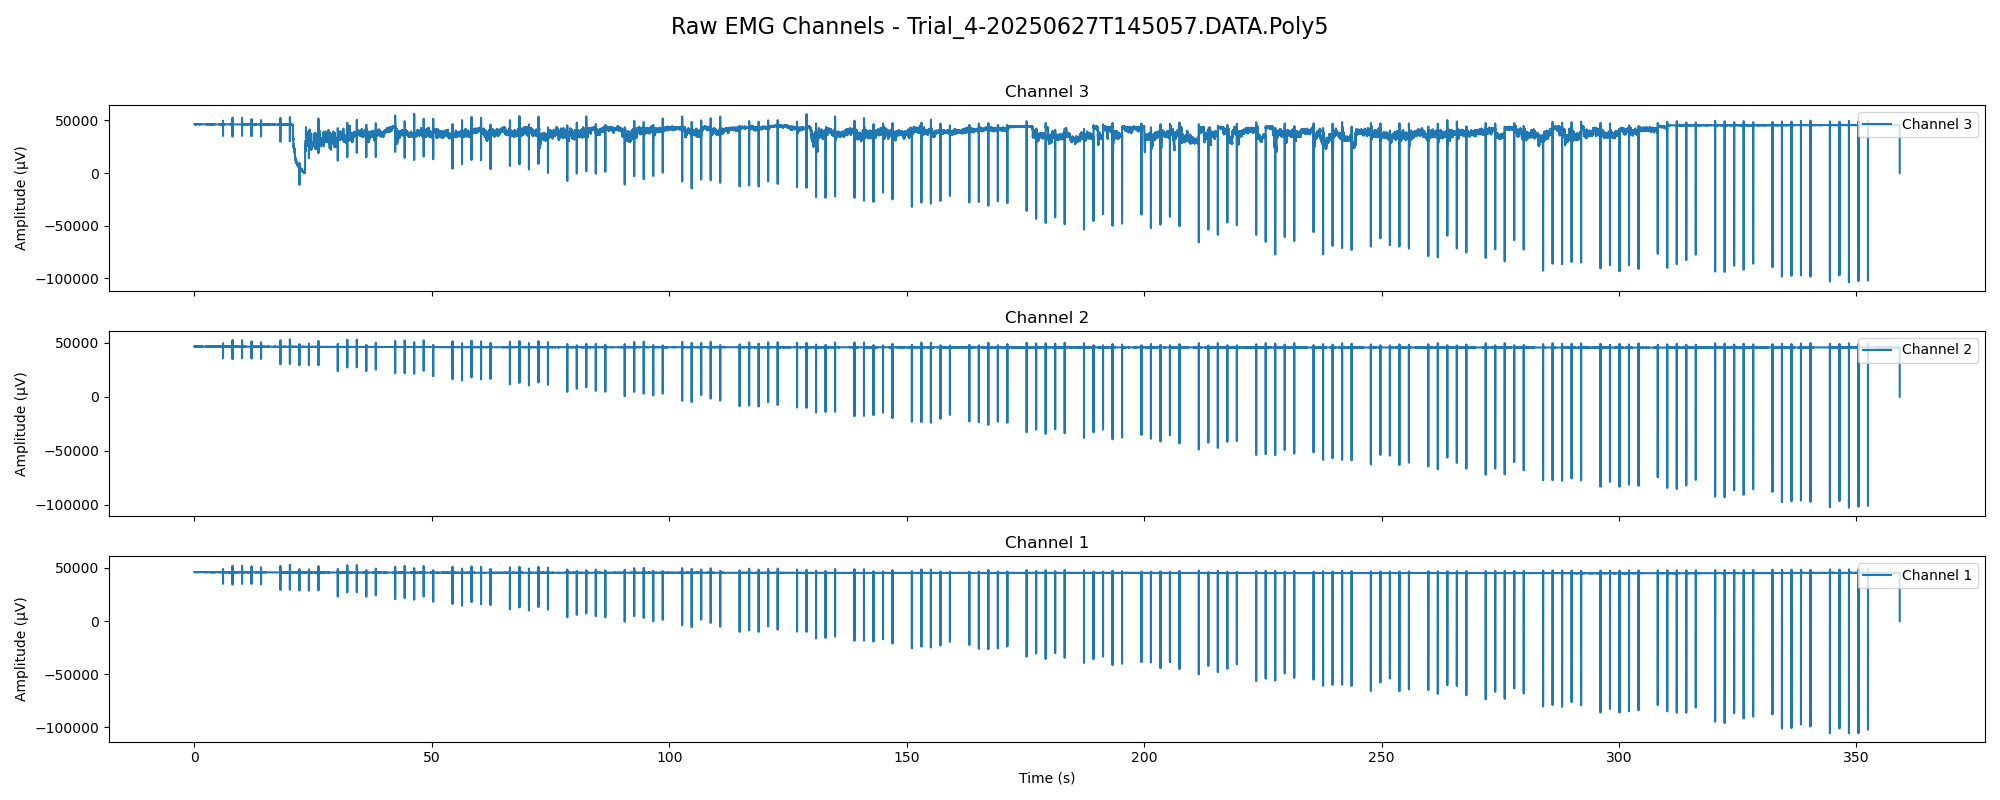

In [295]:
selected_channels = [3, 2, 1]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    ch_names = reader.ch_names
    sample_rate = reader.sample_rate

    # Extract EMG and time axis
    trigger = samples[73,:]
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # Plot for this file
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, emg[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")  # Add title for each subplot

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Raw EMG Channels - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
#Raw EMG Channels with Spike Artifacts Removal
selected_channels = [35, 30, 37]  # the EMG channel indices you care about

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples     = reader.samples          # shape: (n_channels, n_samples)
    sample_rate = reader.sample_rate

    # split out trigger & EMG
    trigger = samples[73, :]              # your digital trigger channel
    emg     = samples[1:65, :].astype(float)  # EMG as float for interpolation

    # 1) detect rising‐edge onsets in the trigger
    #    Adjust the threshold if your trigger amplitude changes
    trig_diff = np.diff(trigger)
    onsets    = np.where(trig_diff > 0.5)[0] + 2

    # 2) build a mask of samples to remove around each spike
    #    here we remove 1 sample before and after the detected peak
    mask = np.zeros(emg.shape[1], dtype=bool)
    for idx in onsets:
        # define window of samples to mask
        start = max(idx - 1, 0)
        end   = min(idx + 2, emg.shape[1])  # +2 because slice end is exclusive
        mask[start:end] = True

    # 3) interpolate each channel over the masked samples
    emg_clean = np.zeros_like(emg)
    x = np.arange(emg.shape[1])
    valid = ~mask
    for ch in range(emg.shape[0]):
        y = emg[ch].copy()
        # set spike samples to NaN
        y[mask] = np.nan
        # linear interpolate over NaNs
        emg_clean[ch] = np.interp(x, x[valid], y[valid])

    # now emg_clean has the spike artifacts removed
    # you can plot it or feed it into your bandpass / smoothing pipeline

    # --- quick plot to check channel 35 before & after ---
    import matplotlib.pyplot as plt
    t = x / sample_rate
    plt.figure(figsize=(12,3))
    plt.plot(t, emg[35],    label='raw ch35', alpha=0.5)
    plt.plot(t, emg_clean[35], label='cleaned ch35', linewidth=1)
    plt.legend()
    plt.xlabel('Time (s)'); plt.ylabel('µV')
    plt.title(f"Artifact removal check — {os.path.basename(file_path)}")
    plt.show()

    # …then continue with your usual bandpass, RMS, etc., on emg_clean


    

In [ ]:
def bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = fs/2
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, x)

def lpf_smooth(sig, cutoff, fs, order=5):
    nyq = fs/2
    b,a = butter(order, cutoff/nyq, btype='low')
    if sig.ndim==1:
        return filtfilt(b,a,sig)
    else:
        return np.vstack([filtfilt(b,a,chan) for chan in sig])

def rms_envelope(sig, window_ms, fs):
    """
    Compute the RMS envelope with a moving window of window_ms.
    Works on 1D or 2D (channels × samples) arrays.
    """
    win_samps = int(window_ms * fs / 1000)
    if win_samps < 1:
        raise ValueError("window_ms too small for given fs")
    # squared signal
    if sig.ndim == 1:
        sq = sig**2
        # moving average
        avg_sq = np.convolve(sq, np.ones(win_samps)/win_samps, mode='same')
        return np.sqrt(avg_sq)
    else:
        # for multi‐channel: apply per row
        env = []
        for chan in sig:
            sq = chan**2
            avg_sq = np.convolve(sq, np.ones(win_samps)/win_samps, mode='same')
            env.append(np.sqrt(avg_sq))
        return np.vstack(env)

fs          = 2000.0        # sampling rate
lowcut      = 20.0          # band-pass low end (Hz)
highcut     = 450.0         # band-pass high end (Hz)
bp_order    = 4

lpf_cutoff  = 10.0          # envelope smoothing cutoff (Hz)
lpf_order   = 4

In [ ]:
selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # --- Bandpass filter all EMG channels ---
    filtered = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        filtered[ch, :] = bandpass_filter(emg[ch, :], lowcut, highcut, sample_rate, bp_order)

    # --- Low-pass smooth all EMG channels ---
    smoothed = lpf_smooth(filtered, lpf_cutoff, sample_rate, lpf_order)

    # --- Plot for selected channels using filtered data ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, filtered[ch_idx], label=f"Channel {ch_idx} (Filtered)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Filtered EMG - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
#Smoothed

selected_channels = [35, 30, 37]  # Replace with the exact indices you want

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]
    time_axis = np.arange(emg_clean.shape[1]) / sample_rate

    # --- Bandpass filter all EMG channels ---
    filtered = np.zeros_like(emg_clean)
    for ch in range(emg_clean.shape[0]):
        filtered[ch, :] = bandpass_filter(emg_clean[ch, :], lowcut, highcut, sample_rate, bp_order)

    # --- Low-pass smooth all EMG channels ---
    smoothed = lpf_smooth(filtered, lpf_cutoff, sample_rate, lpf_order)

    # --- Plot for selected channels ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, smoothed[ch_idx], label=f"Channel {ch_idx}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Filtered & Smoothed EMG - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


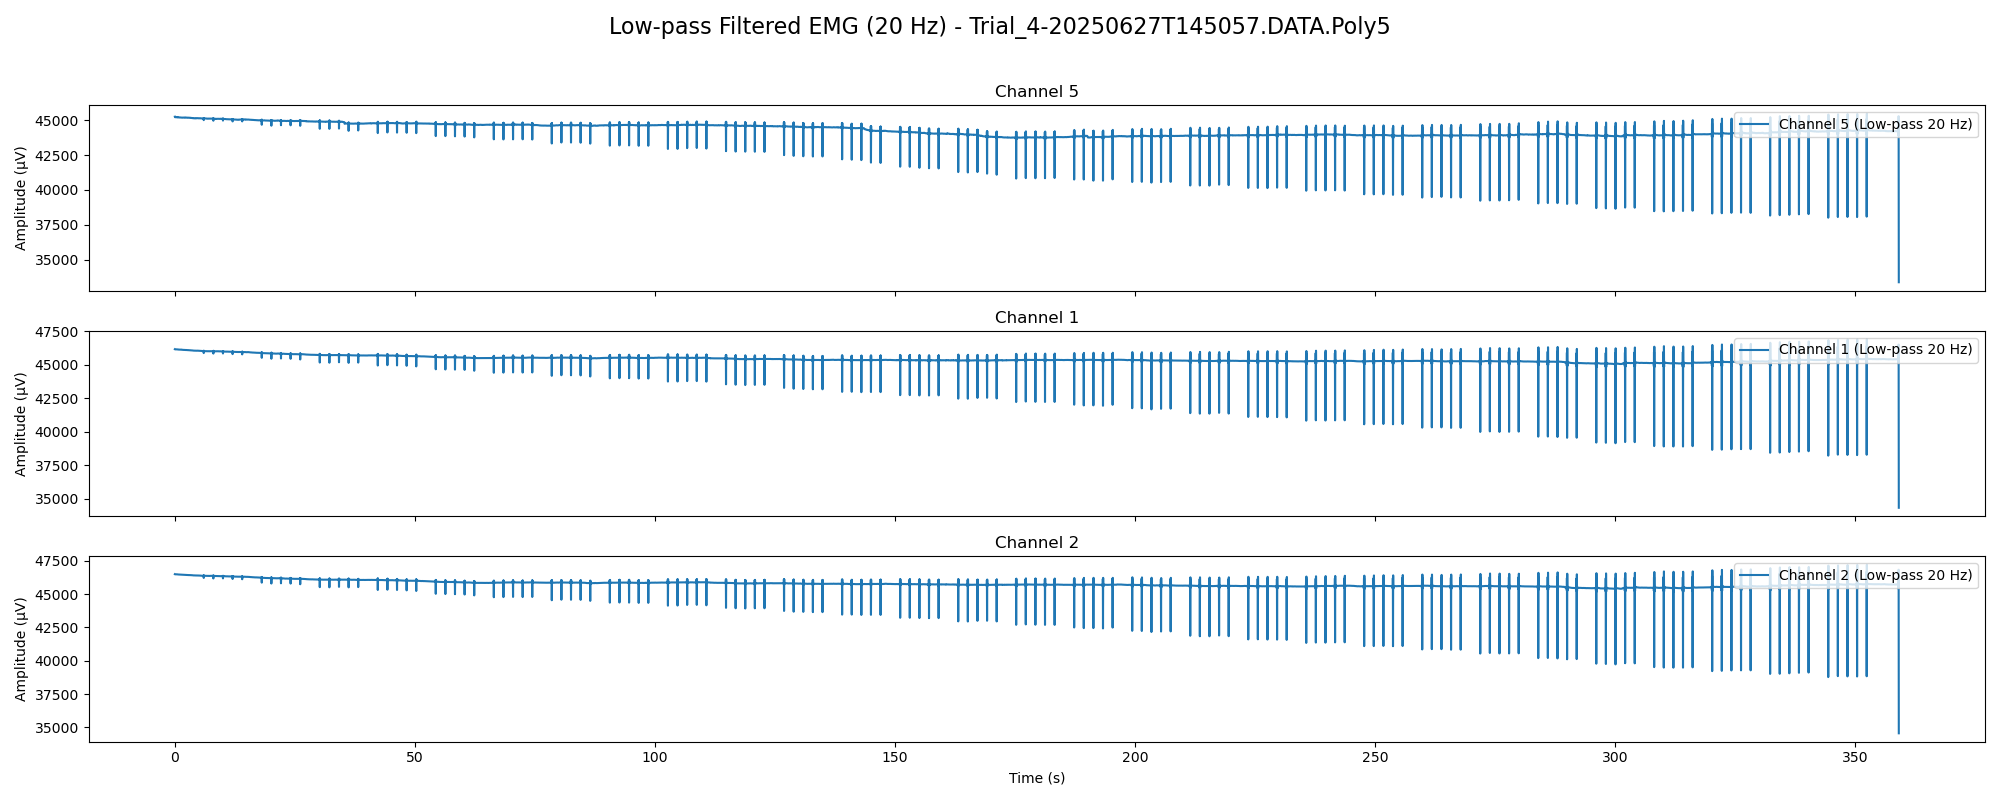

In [304]:
#  ONLY Bandpassing RAW EMG data in order to use for STA

selected_channels = [5, 1, 2]  # Replace with the exact indices you want
lpf_cutoff = 20.0  # Low-pass cutoff frequency (Hz)
lpf_order = 4

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    emg = samples[1:65, :]  # (n_chan, n_samp)
    time_axis = np.arange(emg.shape[1]) / sample_rate

    # --- Low-pass filter all EMG channels at 20 Hz ---
    emg_lpf = np.zeros_like(emg)
    for ch in range(emg.shape[0]):
        nyq = sample_rate / 2
        b, a = butter(lpf_order, lpf_cutoff / nyq, btype='low')
        emg_lpf[ch, :] = filtfilt(b, a, emg[ch, :])

    # --- Plot for selected channels ---
    num_selected = len(selected_channels)
    fig, axes = plt.subplots(num_selected, 1, sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, emg_lpf[ch_idx], label=f"Channel {ch_idx} (Low-pass 20 Hz)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Low-pass Filtered EMG (20 Hz) - {os.path.basename(file_path)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
#RMS envlope instead of smoothing, better results

selected_channels = [35, 30, 37]  # Replace with the exact indices you want
for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate
    emg         = samples[1:65, :]                     # (n_chan, n_samp)
    time_axis   = np.arange(emg_clean.shape[1]) / sample_rate

    # --- 1) Band‑pass filter all EMG channels ---
    filtered = np.zeros_like(emg_clean)
    for ch in range(emg_clean.shape[0]):
        filtered[ch, :] = bandpass_filter(
            emg_clean[ch, :],
            lowcut, highcut,
            sample_rate, bp_order
        )

    # --- 2) Compute 50 ms RMS envelope on each channel ---
    window_ms = 50
    rms_env   = rms_envelope(filtered, window_ms, sample_rate)

    # --- 3) (Optional) Low‑pass smooth the RMS envelope at 10 Hz ---
    rms_smooth = lpf_smooth(rms_env, lpf_cutoff, sample_rate, lpf_order)

    # --- 4) Plot the RMS‐based traces for your selected channels ---
    fig, axes = plt.subplots(len(selected_channels), 1,
                             sharex=True, figsize=(20, 8))
    plt.subplots_adjust(hspace=0.5)

    for ax, ch_idx in zip(axes, selected_channels):
        ax.plot(time_axis, rms_smooth[ch_idx],
                label=f"Channel {ch_idx} RMS")
        ax.set_ylabel("RMS (µV)")
        ax.legend(loc="upper right")
        ax.set_title(f"Channel {ch_idx}")

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"50 ms RMS Envelope – {os.path.basename(file_path)}",
                 fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
from sklearn.decomposition import PCA, FastICA

# --- PCA/ICA on RMS envelope (channels x samples) ---
# Transpose to (samples, channels) for decomposition
rms_for_decomp = rms_smooth.T  # shape: (n_samples, n_channels)

# --- PCA ---
pca = PCA(n_components=5)  # Adjust n_components as needed
pca_components = pca.fit_transform(rms_for_decomp)  # shape: (n_samples, n_components)

# --- ICA ---
ica = FastICA(n_components=5, random_state=0)
ica_components = ica.fit_transform(rms_for_decomp)  # shape: (n_samples, n_components)

# --- Plot first 3 PCA components ---
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(time_axis, pca_components[:, i], label=f'PCA Comp {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Component Value')
plt.title('First 3 PCA Components of RMS HD-EMG')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot first 3 ICA components ---
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(time_axis, ica_components[:, i], label=f'ICA Comp {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Component Value')
plt.title('First 3 ICA Components of RMS HD-EMG')
plt.legend()
plt.tight_layout()
plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


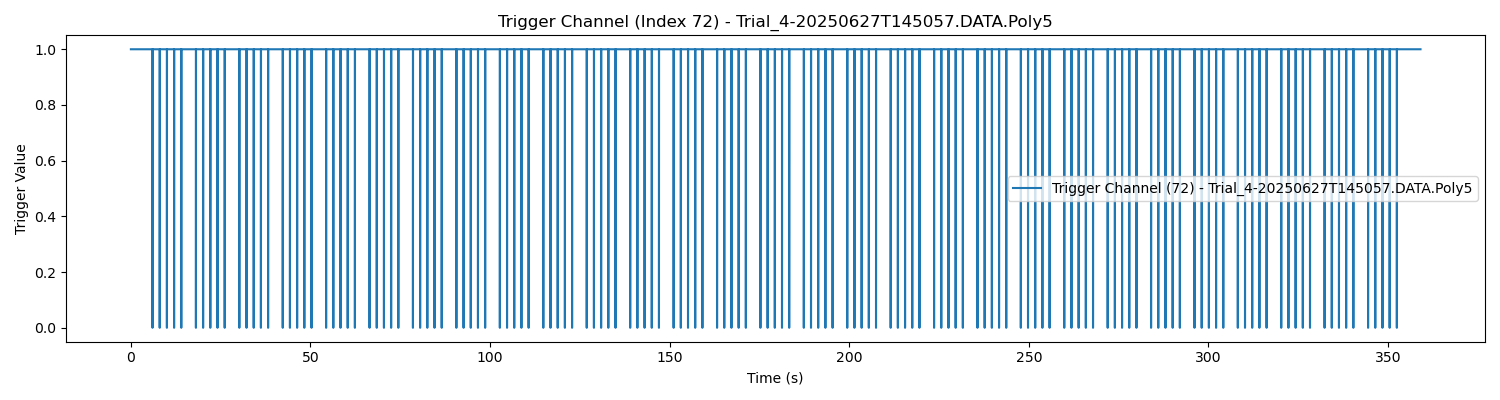

In [259]:
# Plot the trigger channel for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[72, :-200]

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:-200], trigger, label=f"Trigger Channel (72) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 72) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


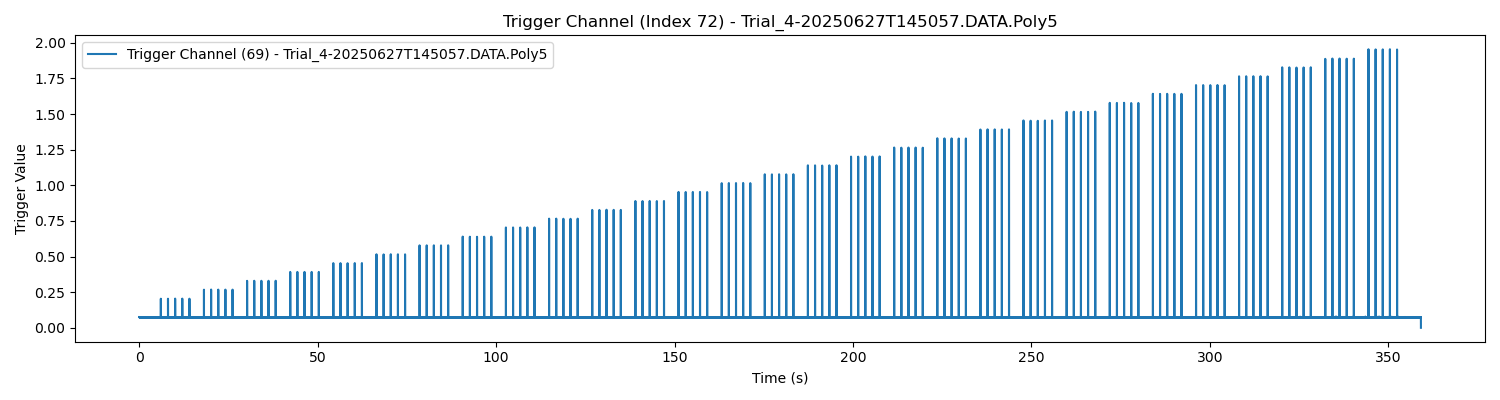

In [260]:
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    aux = samples[69, :]

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, aux, label=f"Trigger Channel (69) - {os.path.basename(file_path)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Trigger Value")
    plt.title(f"Trigger Channel (Index 72) - {os.path.basename(file_path)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Function to find peaks in a trigger waveform and convert to current

def trigger_peaks_to_current(trigger, 
                             fs=None, 
                             height=None, 
                             distance=None):
    """
    Given a 1D trigger waveform, find all local peaks and convert
    each peak-voltage to current in mA using 80mA/10V scaling. shawwwww

    Parameters
    ----------
    trigger : array-like
        1D trigger channel (voltages).
    fs : float, optional
        Sampling rate (Hz). If provided, will also return times in seconds.
    height : float or tuple, optional
        Passed to scipy.signal.find_peaks to threshold peak heights.
    distance : int, optional
        Passed to scipy.signal.find_peaks to impose a minimum sample 
        distance between peaks.

    Returns
    -------
    peaks_idx : ndarray
        Sample indices of each detected peak.
    times_s : ndarray or None
        Time of each peak in seconds (if fs given), else None.
    volts   : ndarray
        Voltage of each peak.
    currents_mA : ndarray
        Converted current for each peak, in mA.
    """
    # 1) find local maxima in the trigger waveform
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)

    # 2) peak voltages
    volts = trigger[peaks_idx]

    # 3) apply conversion: 80 mA per 10 V => 8 mA/V
    currents_mA = (80 / 10) * volts

    # optional time vector
    times_s = peaks_idx / fs if fs is not None else None

    return peaks_idx, times_s, volts, currents_mA


# assume `trigger` is your NumPy array and sample_rate is in Hz
idx, t_peak, v_peak, i_peak = trigger_peaks_to_current(
    aux,
    fs=sample_rate,
    height=0.1,     # e.g. only detect peaks above 0.1 V
    distance=100    # e.g. at least 100 samples between peaks
)

for k, (vv, ii) in enumerate(zip(v_peak, i_peak)):
    print(f"Peak #{k:2d}: {vv:.3f} V  →  {ii:.2f} mA")



Peak # 0: 0.204 V  →  1.63 mA
Peak # 1: 0.204 V  →  1.63 mA
Peak # 2: 0.205 V  →  1.64 mA
Peak # 3: 0.205 V  →  1.64 mA
Peak # 4: 0.204 V  →  1.63 mA
Peak # 5: 0.267 V  →  2.14 mA
Peak # 6: 0.268 V  →  2.15 mA
Peak # 7: 0.268 V  →  2.14 mA
Peak # 8: 0.268 V  →  2.14 mA
Peak # 9: 0.268 V  →  2.14 mA
Peak #10: 0.329 V  →  2.64 mA
Peak #11: 0.330 V  →  2.64 mA
Peak #12: 0.330 V  →  2.64 mA
Peak #13: 0.330 V  →  2.64 mA
Peak #14: 0.330 V  →  2.64 mA
Peak #15: 0.392 V  →  3.14 mA
Peak #16: 0.392 V  →  3.14 mA
Peak #17: 0.392 V  →  3.14 mA
Peak #18: 0.392 V  →  3.14 mA
Peak #19: 0.392 V  →  3.14 mA
Peak #20: 0.454 V  →  3.63 mA
Peak #21: 0.454 V  →  3.63 mA
Peak #22: 0.453 V  →  3.63 mA
Peak #23: 0.454 V  →  3.63 mA
Peak #24: 0.454 V  →  3.63 mA
Peak #25: 0.516 V  →  4.13 mA
Peak #26: 0.515 V  →  4.12 mA
Peak #27: 0.516 V  →  4.13 mA
Peak #28: 0.516 V  →  4.13 mA
Peak #29: 0.515 V  →  4.12 mA
Peak #30: 0.579 V  →  4.63 mA
Peak #31: 0.579 V  →  4.63 mA
Peak #32: 0.579 V  →  4.63 mA
Peak #33: 

In [263]:
print(i_peak)

[ 1.63180554  1.63154209  1.63845563  1.63741088  1.63276863  2.13892007
  2.14738703  2.1432445   2.14290833  2.1420815   2.63591409  2.63963866
  2.63818526  2.6398387   2.64113784  3.13527918  3.13646007  3.13647819
  3.13566971  3.13636017  3.63038349  3.63040161  3.62610435  3.63260007
  3.6328907   4.12701416  4.11995506  4.12879467  4.1255784   4.12286234
  4.62864113  4.62822342  4.62953138  4.62588835  4.630867    5.11938477
  5.1123805   5.10993671  5.11436081  5.11556911  5.63225889  5.63233185
  5.62988806  5.63782787  5.6375556   6.1267271   6.12819004  6.1204772
  6.11821508  6.1267457   6.61639881  6.61507273  6.62814569  6.62131405
  6.61702585  7.11712694  7.11421061  7.11982489  7.11421061  7.11829853
  7.62710285  7.62360525  7.62466812  7.62633991  7.61907196  8.11929989
  8.12501431  8.12432384  8.13041115  8.12143517  8.61769295  8.61258698
  8.61773872  8.61346817  8.62134552  9.12031078  9.11855698  9.10803699
  9.12131882  9.12418079  9.60996437  9.60739326  9.

In [ ]:
# Find falling edges for all selected flexion files
for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate
    time_axis = np.arange(samples.shape[1]) / sample_rate
    trigger = samples[73, :]

    # Find falling edges
    falling_edges = np.where(np.diff(trigger) < -0.5)[0] + 1  # +1 to get the index after the transition
    print(f"\nFile: {os.path.basename(file_path)}")
    print("Indices where trigger goes from 1 to 0:", falling_edges)

    # Time between each trigger (in seconds)
    falling_times = time_axis[falling_edges]
    intervals = np.diff(falling_times)
    print("Time between each trigger (s):", intervals)

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.


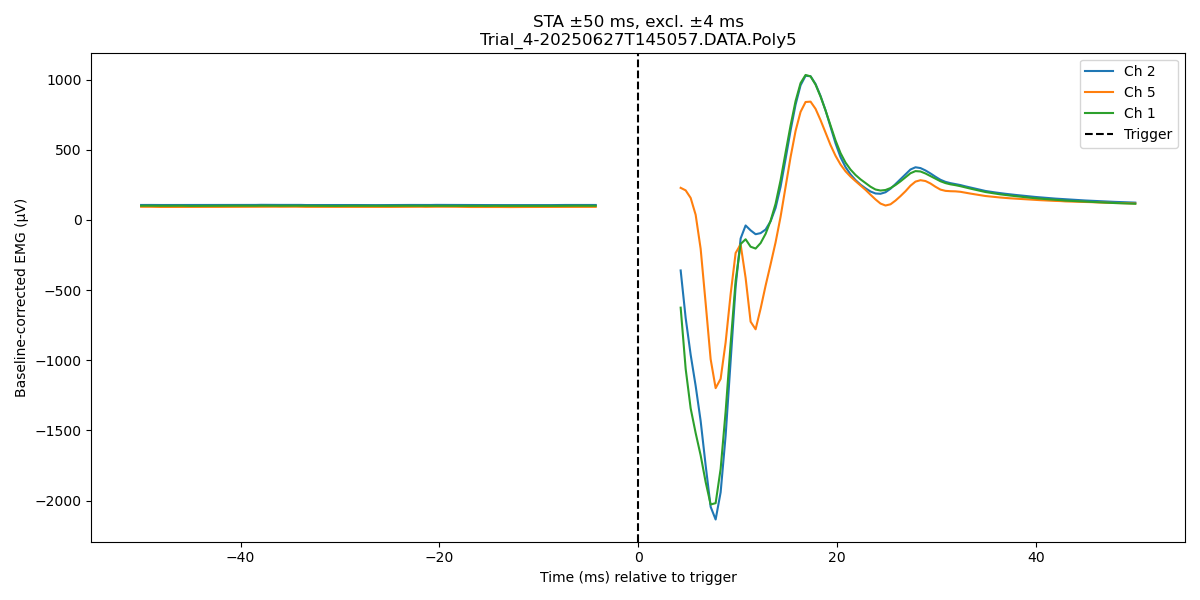

In [305]:
# how much of the snippet you want around each spike
sta_window_ms = 50    # ±200 ms for STA
blank_ms      = 4      # only exclude ±4 ms around t=0

selected_channels = [2, 5, 1]

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate

    emg     = samples[1:65, :]
    trigger = samples[72, :]

    # compute how many samples for each window
    sta_window_samps = int(sta_window_ms * sample_rate / 1000)
    total_window     = 2 * sta_window_samps

    # find valid trigger indices
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1
    valid_triggers = trigger_onsets[
        (trigger_onsets > sta_window_samps) &
        (trigger_onsets < trigger.shape[0] - sta_window_samps)
    ]

    # collect baseline-corrected snippets
    snippets = []
    for idx in valid_triggers:
        snippet  = emg[:, idx - sta_window_samps : idx + sta_window_samps]
        baseline = snippet[:, :sta_window_samps].mean(axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    # stack into shape (n_trigs, n_ch, n_time)
    snips = np.stack(snippets, axis=0).astype(float)

    # build a time‐axis centered on t=0
    sta_time = np.linspace(-sta_window_ms, sta_window_ms, total_window)

    # 1D boolean mask over time: True inside ±blank_ms
    time_mask = np.abs(sta_time) <= blank_ms  # shape: (total_window,)

    # … everything up through stacking your snippets …
snips = np.stack(snippets, axis=0).astype(float)    # shape: (n_trigs, n_ch, total_window)

# build a 1-D boolean mask over time
sta_time  = np.linspace(-sta_window_ms, sta_window_ms, total_window)
time_mask = np.abs(sta_time) <= blank_ms            # shape: (total_window,)

# manually broadcast to full shape
mask_full = np.broadcast_to(time_mask[None, None, :], snips.shape)
# now create a masked array with the exact same shape
snips_ma  = np.ma.array(snips, mask=mask_full)

# compute STA ignoring the masked region
sta = snips_ma.mean(axis=0).filled(np.nan)         # shape: (n_ch, total_window)

# plotting
plt.figure(figsize=(12,6))
for ch in selected_channels:
    plt.plot(sta_time, sta[ch], label=f'Ch {ch}')
plt.axvline(0, color='k', linestyle='--', label='Trigger')
plt.xlabel('Time (ms) relative to trigger')
plt.ylabel('Baseline-corrected EMG (µV)')
plt.title(f'STA ±{sta_window_ms} ms, excl. ±{blank_ms} ms\n'
          f'{os.path.basename(file_path)}')
plt.legend()
plt.tight_layout()
plt.show()





In [306]:
# Compute peak-to-peak amplitude for each channel in the STA for all flexion_files

window_ms = 50  # window before and after trigger in ms
selected_channels = [2, 5, 1]  
all_peak_to_peak = {}
for file_path in flexion_files:
    
    reader = Poly5Reader(file_path)
    samples = reader.samples
    sample_rate = reader.sample_rate  

    emg = samples[1:65, :]
    trigger = samples[72, :]
    window_samples = int(window_ms * sample_rate / 1000)
    total_window = 2 * window_samples

    # Find trigger events (rising edges)
    trigger_diff = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1

    # Only keep triggers far enough from start/end for window
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) & (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    # Extract and baseline-correct EMG snippets around each trigger
    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippet_corrected = snippet - baseline
        snippets.append(snippet_corrected)

    if len(snippets) == 0:
        print(f"No valid triggers found in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # shape: (n_triggers, n_channels, window)
    sta = np.mean(snippets, axis=0)  # shape: (n_channels, window)

    # Compute peak-to-peak amplitude for each channel in the STA
    peak_to_peak = np.ptp(sta, axis=1)  # shape: (n_channels,)
    all_peak_to_peak[os.path.basename(file_path)] = peak_to_peak

    # Print results for selected channels
    print(f"\nFile: {os.path.basename(file_path)}")
    for ch in selected_channels:
        print(f"  Channel {ch}: Peak-to-peak amplitude = {peak_to_peak[ch]:.2f} µV")

Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.

File: Trial_4-20250627T145057.DATA.Poly5
  Channel 2: Peak-to-peak amplitude = 68508.79 µV
  Channel 5: Peak-to-peak amplitude = 66010.35 µV
  Channel 1: Peak-to-peak amplitude = 67805.36 µV


In [ ]:
#Higest peak-to-peak amplitude across all files - does not account for SNR/Impedance
window_ms = 4  # window before and after trigger in ms
all_peak_to_peak = {}

for file_path in flexion_files:
    reader = Poly5Reader(file_path)
    samples     = reader.samples
    sample_rate = reader.sample_rate  

    emg     = samples[1:65, :]   # assume channels 1–64 are EMG
    trigger = samples[72, :]
    window_samples = int(window_ms * sample_rate / 1000)

    # 1) Find trigger onsets
    trigger_diff   = np.diff(trigger)
    trigger_onsets = np.where(trigger_diff > 0.5)[0] + 1

    # 2) Keep only onsets far enough from edges
    valid_triggers = trigger_onsets[
        (trigger_onsets > window_samples) &
        (trigger_onsets < trigger.shape[0] - window_samples)
    ]

    snippets = []
    for idx in valid_triggers:
        snippet = emg[:, idx - window_samples : idx + window_samples]
        baseline = np.mean(snippet[:, :window_samples], axis=1, keepdims=True)
        snippets.append(snippet - baseline)

    if not snippets:
        print(f"No valid triggers in {os.path.basename(file_path)}")
        continue

    snippets = np.stack(snippets, axis=0)  # (n_triggers, n_channels, window)
    sta      = np.mean(snippets, axis=0)   # (n_channels, window)

    # 3) Peak-to-peak for every channel
    peak_to_peak = np.ptp(sta, axis=1)     # length = n_channels
    all_peak_to_peak[os.path.basename(file_path)] = peak_to_peak

    # 4) Find the “best” channel
    best_ch   = int(np.argmax(peak_to_peak))
    best_val  = peak_to_peak[best_ch]

    # 5) Print summary
    print(f"\nFile: {os.path.basename(file_path)}")
    print(f"  Best channel → #{best_ch} with {best_val:.2f} µV pp-amp")

    # (Optional) If you still want to see all channels’ values:
    # for ch, val in enumerate(peak_to_peak):
    #     print(f"    Ch {ch:2d}: {val:.2f} µV")


In [303]:
import os
import numpy as np
from scipy.signal import find_peaks

window_ms = 50
all_peak_to_peak = {}
all_baseline_rms = {}

for file_path in flexion_files:
    reader      = Poly5Reader(file_path)
    samples     = reader.samples
    fs          = reader.sample_rate
    emg         = samples[1:65, :]   # channels × time
    trigger     = samples[72, :]
    win_samps   = int(window_ms * fs / 1000)

    # --- find triggers & build STA ---
    diffs    = np.diff(trigger)
    onsets   = np.where(diffs > 0.5)[0] + 1
    valid    = onsets[(onsets>win_samps)&(onsets<emg.shape[1]-win_samps)]
    snippets = []
    for idx in valid:
        snip     = emg[:, idx-win_samps:idx+win_samps]
        baseline = snip[:, :win_samps].mean(axis=1, keepdims=True)
        snippets.append(snip - baseline)
    if not snippets:
        continue
    sta = np.mean(np.stack(snippets), axis=0)  # (channels, window)

    # --- 1) peak-to-peak of STA ---
    ptp       = np.ptp(sta, axis=1)            # (channels,)
    all_peak_to_peak[os.path.basename(file_path)] = ptp

    # --- 2) baseline RMS as noise proxy ---
    first_trig = valid[0]
    noise_win  = int(0.100 * fs)  # 100 ms
    noise_seg  = emg[:, first_trig-noise_win : first_trig]
    rms_noise  = np.sqrt(np.mean(noise_seg**2, axis=1))  # (channels,)
    all_baseline_rms[os.path.basename(file_path)] = rms_noise

  # --- 3) combined score and top-3 channels, excluding NaNs ---
score = ptp / rms_noise   # shape (n_channels,)

# create a boolean mask of finite scores
valid_mask = np.isfinite(score)

# get indices of channels with valid scores
valid_chs = np.where(valid_mask)[0]

# sort only the valid scores in descending order
sorted_valid = valid_chs[np.argsort(score[valid_mask])[::-1]]

# pick top 3 (if there are at least 3 valid channels)
top4 = sorted_valid[:4]

# --- 4) Print summary ---
print(f"\nFile: {os.path.basename(file_path)}")
print("→ Top 3 channels by (ptp ÷ baseline RMS):")
for rank, ch in enumerate(top4, start=1):
    print(f"   {rank}. Channel {ch} — score {score[ch]:.2f}, ptp {ptp[ch]:.1f} µV, rms {rms_noise[ch]:.1f} µV")





Reading file  G:/My Drive/Research/Data/electrostim_data/Doug 6-27/20250627-Recruitment Curve Data/Trial_4-20250627T145057.DATA.Poly5
	 Number of samples:  718254 
	 Number of channels:  75 
	 Sample rate: 2000 Hz
Done reading data.

File: Trial_4-20250627T145057.DATA.Poly5
→ Top 3 channels by (ptp ÷ baseline RMS):
   1. Channel 3 — score 1.54, ptp 71166.4 µV, rms 46290.6 µV
   2. Channel 2 — score 1.48, ptp 68508.8 µV, rms 46357.7 µV
   3. Channel 1 — score 1.47, ptp 67805.4 µV, rms 46001.6 µV
   4. Channel 5 — score 1.46, ptp 66010.3 µV, rms 45094.2 µV


C:\Users\Dell\AppData\Local\Temp\ipykernel_56080\784747597.py:42: RuntimeWarning: invalid value encountered in divide
  score = ptp / rms_noise   # shape (n_channels,)


In [289]:

baseline_samples = int(0.005 * sample_rate)  # use 5 ms pre-stim for noise

snr = []
for ch in range(sta.shape[0]):
    # 1) signal = peak-to-peak in the post-stimulus STA
    sig = np.ptp(sta[ch, :])
    # 2) noise = baseline standard deviation
    noise = np.std(sta[ch, :baseline_samples])
    snr.append(sig / noise if noise > 0 else 0)

snr = np.array(snr)

# find the top 3 channels by SNR
top3_idx = np.argsort(snr)[::-1][:3]  # descending sort, take first 3

print("→ Top 3 channels by SNR:")
for rank, ch in enumerate(top3_idx, start=1):
    print(f"   {rank}. Channel {ch} (SNR = {snr[ch]:.1f})")


→ Top 3 channels by SNR:
   1. Channel 7 (SNR = 266996.6)
   2. Channel 19 (SNR = 263287.3)
   3. Channel 0 (SNR = 218469.0)


Plotting recruitment curve for Channel 5


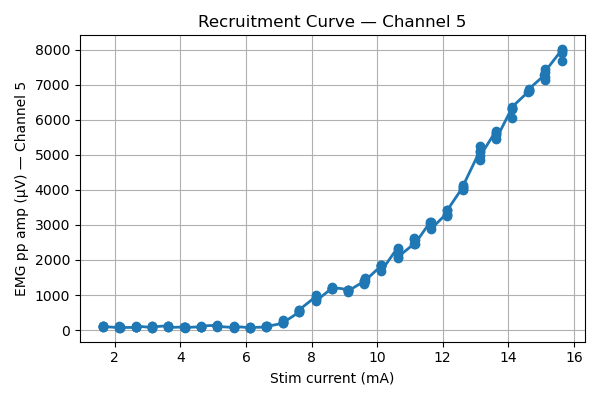

In [307]:
# ——— 1) Helper function ———
def trigger_peaks_to_current(trigger, fs=None, height=None, distance=None):
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)
    volts    = trigger[peaks_idx]
    currents = (80/10) * volts
    times_s  = peaks_idx / fs if fs is not None else None
    return peaks_idx, times_s, volts, currents

# ——— 2) User settings ———
channel_to_plot = 5     # ← set this to the channel you want to visualize
win_start_ms    = 6       # window start (ms) after pulse artifact
win_end_ms      = 30      # window end (ms) after pulse artifact

# ——— 3) Load data ———
# reader       = Poly5Reader(filename)
# aux          = reader.samples[trigger_channel_index]
# emg          = reader.samples[1:65, :]      # shape (n_channels, n_samples)
# sample_rate  = reader.sample_rate

# ——— 4) Detect pulses & convert ———
peaks_idx, times_s, v_peak, i_peak = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

# ——— 5) Extract per-pulse EMG response for one channel ———
win_start = int(win_start_ms * sample_rate / 1000)
win_end   = int(win_end_ms   * sample_rate / 1000)

emg_resp = []
for idx in peaks_idx:
    seg = emg[channel_to_plot, idx + win_start : idx + win_end]
    emg_resp.append(np.ptp(seg))
emg_resp = np.array(emg_resp)

# Report which channel we're plotting
print(f"Plotting recruitment curve for Channel {channel_to_plot}")

# ——— 6) Build & plot recruitment curve ———
pairs = sorted(zip(i_peak, emg_resp), key=lambda x: x[0])
I_sorted, R_sorted = zip(*pairs)

plt.figure(figsize=(6,4))
plt.plot(I_sorted, R_sorted, 'o-', linewidth=2, markersize=6)
plt.xlabel('Stim current (mA)')
plt.ylabel(f'EMG pp amp (µV) — Channel {channel_to_plot}')
plt.title(f'Recruitment Curve — Channel {channel_to_plot}')
plt.grid(True)
plt.tight_layout()
plt.show()

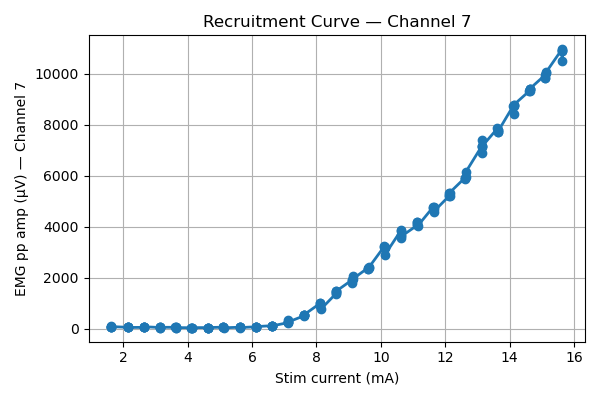

In [286]:
# ——— 1) Helper function ———
def trigger_peaks_to_current(trigger, fs=None, height=None, distance=None):
    peaks_idx, props = find_peaks(trigger, height=height, distance=distance)
    volts    = trigger[peaks_idx]
    currents = (80/10) * volts
    times_s  = peaks_idx / fs if fs is not None else None
    return peaks_idx, times_s, volts, currents

# ——— 2) User settings ———
channel_to_plot = 7     # ← set this to the one channel you want
win_start_ms    = 6       # window start (ms) after pulse artifact
win_end_ms      = 30      # window end (ms) after pulse artifact

# ——— 3) Load data ———
# reader       = Poly5Reader(filename)
# aux          = reader.samples[trigger_channel_index]
# emg          = reader.samples[1:65, :]      # shape (n_channels, n_samples)
# sample_rate  = reader.sample_rate

# ——— 4) Detect pulses & convert ———
peaks_idx, times_s, v_peak, i_peak = trigger_peaks_to_current(
    aux, fs=sample_rate, height=0.1, distance=100
)

# ——— 5) Extract per-pulse EMG response for one channel ———
win_start = int(win_start_ms * sample_rate / 1000)
win_end   = int(win_end_ms   * sample_rate / 1000)

emg_resp = []
for idx in peaks_idx:
    seg = emg[channel_to_plot, idx + win_start : idx + win_end]
    emg_resp.append(np.ptp(seg))
emg_resp = np.array(emg_resp)

# ——— 6) Build & plot recruitment curve ———
pairs = sorted(zip(i_peak, emg_resp), key=lambda x: x[0])
I_sorted, R_sorted = zip(*pairs)

plt.figure(figsize=(6,4))
plt.plot(I_sorted, R_sorted, 'o-', linewidth=2, markersize=6)
plt.xlabel('Stim current (mA)')
plt.ylabel(f'EMG pp amp (µV) — Channel {channel_to_plot}')
plt.title(f'Recruitment Curve — Channel {channel_to_plot}')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:


stim_intensity_dict = {
    'trial_6_FLX-20250627_151916.poly5': 5,
    'trial_7_FLX-20250627_152122.poly5': 3,
    'trial_8_FLX-20250627_152242.poly5': 4,
    # Add more/change as needed
}

channel_to_plot = 37  # Choose the channel for the recruitment curve

intensities = []
amplitudes = []

for fname, peak_to_peak in all_peak_to_peak.items():
    if fname in stim_intensity_dict:
        intensities.append(stim_intensity_dict[fname])
        amplitudes.append(peak_to_peak[channel_to_plot])

# Sort by intensity 
if intensities:
    sorted_pairs = sorted(zip(intensities, amplitudes))
    sorted_intensities, sorted_amplitudes = zip(*sorted_pairs)

    plt.figure(figsize=(8, 5))
    plt.plot(sorted_intensities, sorted_amplitudes)
    plt.xlabel('Stimulation Intensity (mA)')
    plt.ylabel(f'Peak-to-Peak Amplitude (µV) - Channel {channel_to_plot}')
    plt.title('Recruitment Curve - Channel {}'.format(channel_to_plot))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No matching trials found between all_peak_to_peak and stim_intensity_dict. 😦")